## Metrics plots

Metrics analysis using all the centers during training.

In [7]:
import os
import sys

# In Pycharm/Dataspell is not needed 
sys.path.append(os.path.expanduser('/home/fmatzkin/fast_dataset_cache/wmh_UtrechtSpace/wmh'))

In [ ]:
from src.datamodules import WMHDataModule
import os

data_root = os.path.expanduser('/home/fmatzkin/fast_dataset_cache/wmh_UtrechtSpace/wmh')
# centers_test = ['UMCL']
centers_test = ['Utrecht', 'Amsterdam', 'Singapore', 'UMCL']
centers_train = ['UtAmSi']

# For plotting, I'll look for the combinations of losses and centers
# in runs_to_compare. If the combination is not there, I'll skip it.

# Compare MEEP vs MEALL
losses = ['CE', 'MEEP-0.03', 'MEALL-0.03', 'KL', 'Focal', 'Dice']
runs_to_compare = {
    'CE UtAmSi': 'training_Utrecht_Amsterdam_Singapore_CE_3684_best',
    'MEEP-0.03 UtAmSi': 'training_Utrecht_Amsterdam_Singapore_MEEP_6996_best',
    'MEALL-0.03 UtAmSi': 'training_Utrecht_Amsterdam_Singapore_MEALL_8766_best',
    'KL UtAmSi': 'training_Utrecht_Amsterdam_Singapore_KL_4655_best',
    'Focal UtAmSi': 'training_Utrecht_Amsterdam_Singapore_Focal_5161_best',
    'Dice UtAmSi': 'training_Utrecht_Amsterdam_Singapore_Dice_3011_best',
}

In [9]:
test_splits = {}
for center in ['Utrecht', 'Amsterdam', 'Singapore']:
    dm = WMHDataModule(data_root, 1, f'training:{center}', [.7, .1, .2],
                       seed=42)
    _, _, ts_spl = dm.generate_splits()
    test_splits[center] = ts_spl

test_splits['UMCL'] = WMHDataModule(data_root, 1, 'training:UMCL', [0, 0, 1]).generate_splits()[2]

In [10]:
# Imports and definitions common to various plots
from medpy.metric.binary import dc as dice_score
from matplotlib import pyplot as plt


def get_gt_paths(test_splits):
    """ Get the ground truth paths for a given test split """
    return [os.path.split(test_splits[i][2])[0] for i in
            range(len(test_splits))]


def entropy(probs, eps=1e-3, apply_mean=True):
    probs = np.clip(probs, eps, 1 - eps)
    if apply_mean:
        return np.mean(-probs * np.log(probs) - (1 - probs) * np.log(1 - probs))
    else:
        return -probs * np.log(probs) - (1 - probs) * np.log(1 - probs)


def get_b_mask_path(subj_path):
    """ Load brain mask

    Given a subject path, check if the brain mask exists. If it does, return its
    path. If it doesn't, create it (using FSLs BET) and return its path.

    :param subj_path: Path to subject folder
    :return: Brain mask path
    """
    b_mask_path = os.path.join(subj_path, 'pre', 'T1_brain_mask.nii.gz')
    if os.path.exists(b_mask_path):
        return b_mask_path
    else:
        t1_path = os.path.join(subj_path, 'pre', 'T1.nii.gz')
        b_t1b_path = os.path.join(subj_path, 'pre', 'T1_brain.nii.gz')
        cmd = f"bet {t1_path} {b_t1b_path} -m"
        os.system(cmd)
        print(f"Created brain mask for {subj_path}")
        return b_mask_path

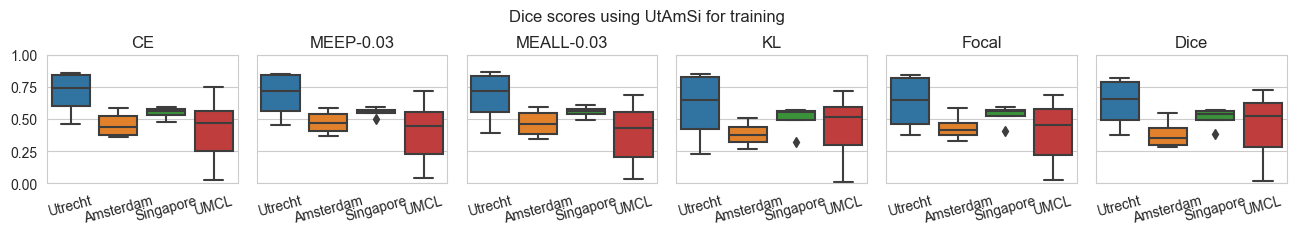

In [11]:
import nibabel as nib
import pandas as pd
import seaborn as sns

use_brain_mask = False

for tr_center in centers_train:  # Three plots: one per center used for training
    plot_data = {}  # Dice scores for each run
    for loss in losses:  # One subplot per loss
        plot_data[loss] = {}
        run_name = runs_to_compare[f'{loss} {tr_center}']
        if f'{loss} {tr_center}' not in runs_to_compare.keys():
            print(f'No run for {run_name}.')
            continue
        for ts_center in centers_test:  # For each center used for testing
            plot_data[loss][ts_center] = []
            gt_pths = get_gt_paths(test_splits[ts_center])  # Lst of tst sbj pts
            for subj_path in gt_pths:
                gt_path = os.path.join(subj_path, f'gt_wmh_{run_name}.nii.gz')
                pred_hard_path = os.path.join(subj_path,
                                              f'pred_wmh_hard_{run_name}.nii.gz')

                pred_hard = nib.load(pred_hard_path).get_fdata()
                gt = nib.load(gt_path).get_fdata()
                if use_brain_mask:
                    b_mask = nib.load(get_b_mask_path(subj_path)).get_fdata()
                    # Mask pred_hard keeping the shape
                    pred_hard = pred_hard * b_mask

                plot_data[loss][ts_center].append(dice_score(pred_hard, gt))
    df = pd.DataFrame(plot_data)

    fig, axes = plt.subplots(1, len(losses), figsize=(16, 2), sharey=True)
    plt.subplots_adjust(wspace=0.1)

    # Create a boxplot for each subplot
    for i, loss in enumerate(losses):
        method_subset = df[loss]
        # # Add to method subset another element with the all the dice scores
        # method_subset['All'] = [dsc for subl in [lst for lst in method_subset] for dsc in subl]

        ax = sns.boxplot(data=method_subset, ax=axes[i])
        ax.set_title(loss)
        ax.set_xticklabels(method_subset.keys())  # set the xticklabels 
        for tick in ax.get_xticklabels():
            tick.set_rotation(15)
        ax.set_ylim([0, 1])

    plt.suptitle(f'Dice scores using {tr_center} for training')
    plt.subplots_adjust(top=0.75)

    plt.show()

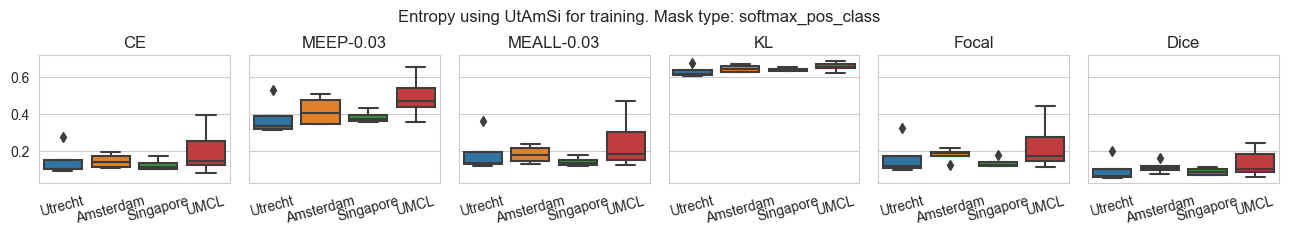

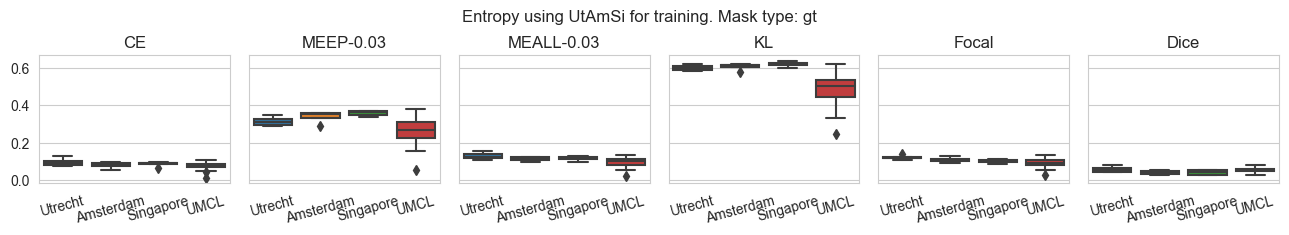

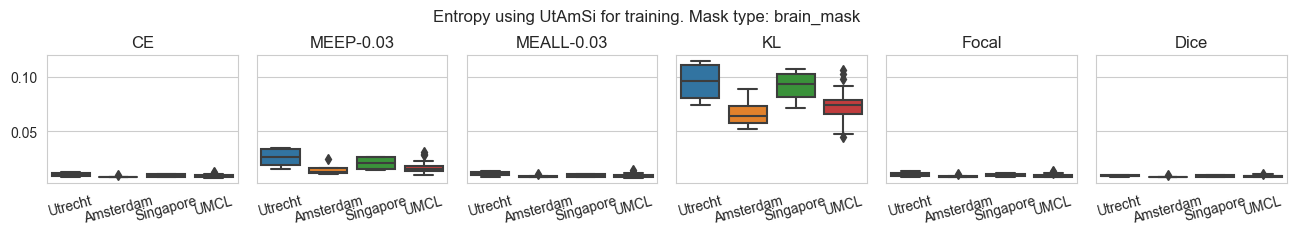

In [12]:
import nibabel as nib
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

mask_type = ['softmax_pos_class', 'gt', 'brain_mask']
for m_type in mask_type:
    for tr_center in centers_train:  # Three plots: one per center used for training
        plot_data = {}  # Entropy scores for each run
        for loss in losses:  # One subplot per loss
            plot_data[loss] = {}
            run_name = runs_to_compare[f'{loss} {tr_center}']
            if f'{loss} {tr_center}' not in runs_to_compare.keys():
                print(f'No run for {run_name}.')
                continue
            for ts_center in centers_test:  # For each center used for testing
                plot_data[loss][ts_center] = []
                gt_pths = get_gt_paths(
                    test_splits[ts_center])  # Lst of tst sbj pts
                for subj_path in gt_pths:
                    gt_path = os.path.join(subj_path,
                                           f'gt_wmh_{run_name}.nii.gz')
                    pred_softmax_path = os.path.join(subj_path,
                                                     f'pred_wmh_softmax_{run_name}.nii.gz')

                    gt = nib.load(gt_path).get_fdata()
                    pred_softmax = nib.load(pred_softmax_path).get_fdata()
                    b_mask = nib.load(get_b_mask_path(subj_path)).get_fdata()

                    pos_class = pred_softmax[:, :, :, 1].flatten()
                    gt_class = gt.flatten()
                    b_mask = b_mask.flatten()

                    if m_type == 'softmax_pos_class':
                        filt = pos_class[np.where(pos_class >= 0.5)[0]]
                    elif m_type == 'gt':
                        filt = pos_class[np.where(gt_class == 1)[0]]
                    else:
                        filt = pos_class[np.where(b_mask == 1)[0]]

                    plot_data[loss][ts_center].append(entropy(filt))
        df = pd.DataFrame(plot_data)

        fig, axes = plt.subplots(1, len(losses), figsize=(16, 2), sharey=True)
        plt.subplots_adjust(wspace=0.1)

        # Create a boxplot for each subplot
        for i, loss in enumerate(losses):
            method_subset = df[loss]
            ax = sns.boxplot(data=method_subset, ax=axes[i])
            ax.set_title(loss)
            ax.set_xticklabels(method_subset.keys())  # set the xticklabels 
            for tick in ax.get_xticklabels():
                tick.set_rotation(15)
            # ax.set_ylim([0, 1])

        plt.suptitle(f'Entropy using {tr_center} for training. '
                     f'Mask type: {m_type}')
        plt.subplots_adjust(top=0.75)

        plt.show()

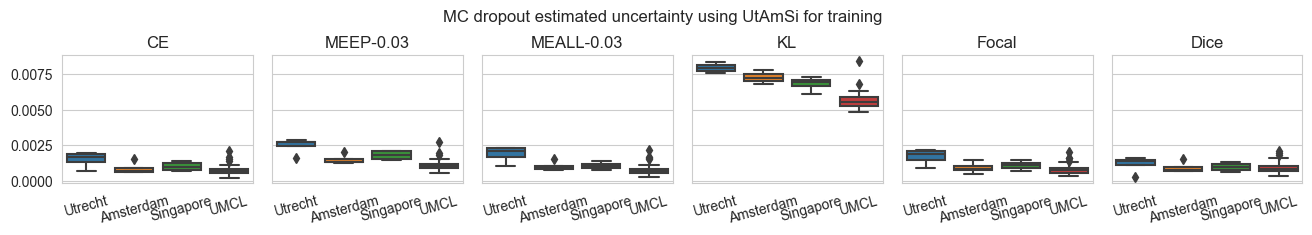

In [13]:
import nibabel as nib
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

for tr_center in centers_train:  # Three plots: one per center used for training
    plot_data = {}  # Entropy scores for each run
    for loss in losses:  # One subplot per loss
        plot_data[loss] = {}
        run_name = runs_to_compare[f'{loss} {tr_center}']
        if f'{loss} {tr_center}' not in runs_to_compare.keys():
            print(f'No run for {run_name}.')
            continue
        for ts_center in centers_test:  # For each center used for testing
            plot_data[loss][ts_center] = []
            gt_pths = get_gt_paths(test_splits[ts_center])  # Lst of tst sbj pts
            for subj_path in gt_pths:
                mc_var_path = os.path.join(subj_path,
                                           f'pred_mc_uncertmc_{run_name}.nii.gz')
                mc_var_img = nib.load(mc_var_path).get_fdata()
                mean_var = mc_var_img.flatten().mean()

                plot_data[loss][ts_center].append(mean_var)
    df = pd.DataFrame(plot_data)

    fig, axes = plt.subplots(1, len(losses), figsize=(16, 2), sharey=True)
    plt.subplots_adjust(wspace=0.1)

    # Create a boxplot for each subplot
    for i, loss in enumerate(losses):
        method_subset = df[loss]
        ax = sns.boxplot(data=method_subset, ax=axes[i])
        ax.set_title(loss)
        ax.set_xticklabels(method_subset.keys())  # set the xticklabels 
        for tick in ax.get_xticklabels():
            tick.set_rotation(15)
        # ax.set_ylim([0, 1])

    plt.suptitle(
        f'MC dropout estimated uncertainty using {tr_center} for training')
    plt.subplots_adjust(top=0.75)

    plt.show()

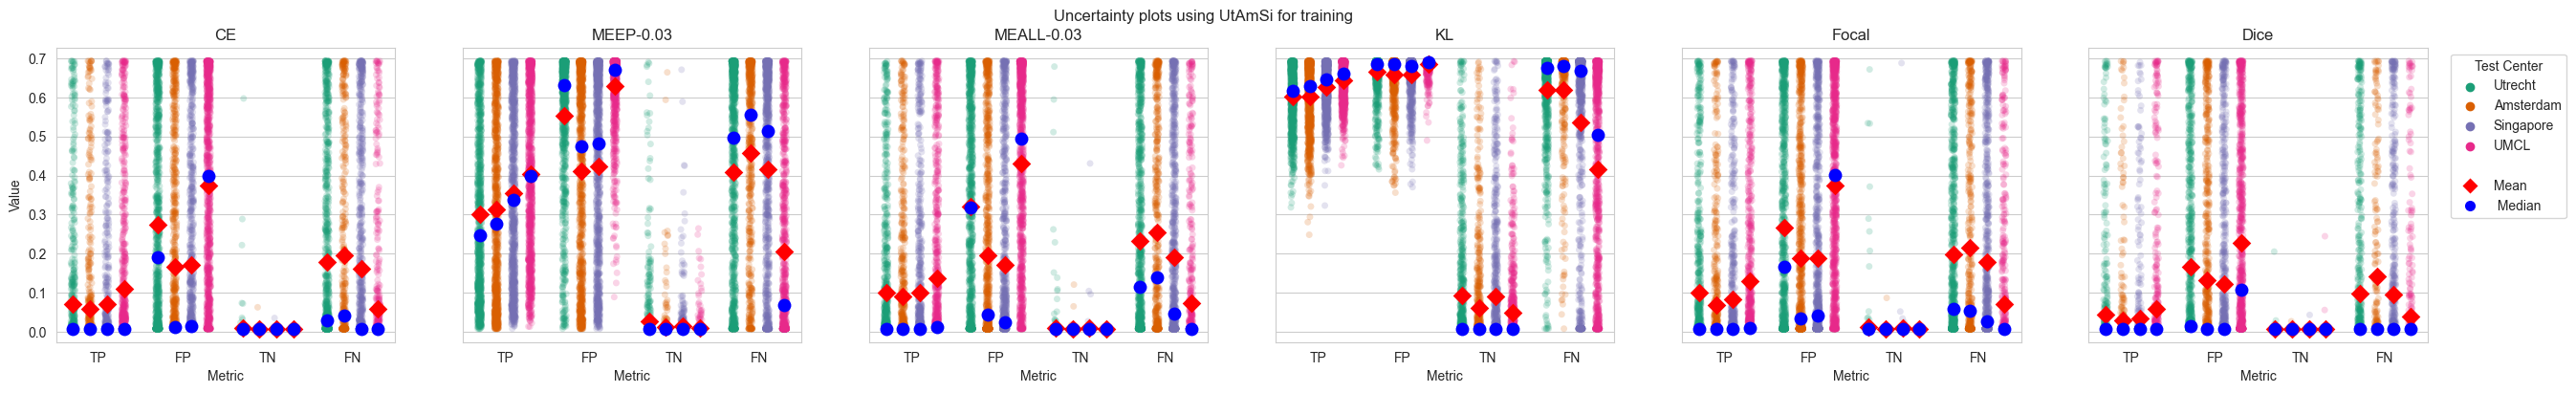

In [14]:
import nibabel as nib
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import \
    Line2D  # Import Line2D for creating custom legend elements

n_samples = 1000

for tr_center in centers_train:  # Three plots: one per center used for training
    plot_data = {}  # Entropy scores for each run
    mean_data = {}
    median_data = {}
    for loss in losses:  # One subplot per loss
        plot_data[loss] = {}  # Three uncertainty plots per loss
        mean_data[loss] = {}
        median_data[loss] = {}
        run_name = runs_to_compare[f'{loss} {tr_center}']
        if f'{loss} {tr_center}' not in runs_to_compare.keys():
            print(f'No run for {run_name}.')
            continue
        for ts_center in centers_test:  # For each center used for testing
            plot_data[loss][ts_center] = {
                "TP": np.array([]),
                "FP": np.array([]),
                "TN": np.array([]),
                "FN": np.array([])
            }
            mean_data[loss][ts_center] = {}
            median_data[loss][ts_center] = {}
            gt_pths = get_gt_paths(
                test_splits[ts_center])  # List of test subject paths
            for subj_path in gt_pths:
                pred_softmax_path = os.path.join(subj_path,
                                                 f'pred_wmh_softmax_{run_name}.nii.gz')
                gt_path = os.path.join(subj_path, f'gt_wmh_{run_name}.nii.gz')

                subj_path = os.path.dirname(pred_softmax_path)

                pred_softmax = nib.load(pred_softmax_path).get_fdata()
                gt = nib.load(gt_path).get_fdata()
                b_mask = nib.load(get_b_mask_path(subj_path)).get_fdata()

                gt_one_hot = np.eye(2, dtype=np.uint8)[gt.astype(int)]

                neg_sftmx = pred_softmax[:, :, :, 0].flatten()
                pos_sftmx = pred_softmax[:, :, :, 1].flatten()
                neg_gt = gt_one_hot[:, :, :, 0].flatten()
                pos_gt = gt_one_hot[:, :, :, 1].flatten()

                b_mask = b_mask.flatten()

                # Brain mask
                thres_brain = np.where(b_mask == 1)[0]
                pos_brain = pos_sftmx[thres_brain]
                neg_brain = neg_sftmx[thres_brain]
                pos_gt_brain = pos_gt[thres_brain]
                neg_gt_brain = neg_gt[thres_brain]

                # TP
                tp = np.where((pos_brain >= 0.5) & (pos_gt_brain == 1))[0]
                tp_unc = entropy(pos_brain[tp], apply_mean=False)
                plot_data[loss][ts_center]["TP"] = np.append(
                    plot_data[loss][ts_center]["TP"], tp_unc)

                # FP
                fp = np.where((pos_brain >= 0.5) & (pos_gt_brain == 0))[0]
                fp_unc = entropy(pos_brain[fp], apply_mean=False)
                plot_data[loss][ts_center]["FP"] = np.append(
                    plot_data[loss][ts_center]["FP"], fp_unc)

                # TN
                tn = np.where((neg_brain >= 0.5) & (neg_gt_brain == 1))[0]
                tn_unc = entropy(neg_brain[tn], apply_mean=False)
                plot_data[loss][ts_center]["TN"] = np.append(
                    plot_data[loss][ts_center]["TN"], tn_unc)

                # FN
                fn = np.where((neg_brain >= 0.5) & (neg_gt_brain == 0))[0]
                fn_unc = entropy(neg_brain[fn], apply_mean=False)
                plot_data[loss][ts_center]["FN"] = np.append(
                    plot_data[loss][ts_center]["FN"], fn_unc)

                # Since there are too many points on TN, we will sample all categories
                # for having just 100 samples
                if n_samples:
                    for category in plot_data[loss][ts_center].keys():
                        if len(plot_data[loss][ts_center][
                                   category]) > n_samples:
                            plot_data[loss][ts_center][
                                category] = np.random.choice(
                                plot_data[loss][ts_center][category], n_samples,
                                replace=False)

            for category in ["TP", "TN", "FP", "FN"]:
                mean_values = np.mean(plot_data[loss][ts_center][category])
                median_values = np.median(plot_data[loss][ts_center][category])
                mean_data[loss][ts_center][category] = mean_values
                median_data[loss][ts_center][category] = median_values

    # Continue with plotting
    fig, axes = plt.subplots(1, len(plot_data), figsize=(32, 4), sharey=True)

    # Create separate strip plots for each loss
    for i, (loss, centers_data) in enumerate(plot_data.items()):
        data = []

        for center, metrics in centers_data.items():
            for metric, values in metrics.items():
                data.extend([(loss, center, metric, value) for value in values])

        df = pd.DataFrame(data,
                          columns=['Loss', 'Test_Center', 'Metric', 'Value'])

        # Create the strip plot
        sns.stripplot(data=df, x='Metric', y='Value', hue='Test_Center',
                      palette='Dark2', jitter=True, alpha=0.2, dodge=True,
                      ax=axes[i])

        # Create the strip plot for mean_data
        mean_df = pd.DataFrame(
            [(loss, center, metric, value) for center, metrics in
             mean_data[loss].items() for metric, value in metrics.items()],
            columns=['Loss', 'Test_Center', 'Metric', 'Value'])
        sns.stripplot(data=mean_df, x='Metric', y='Value', hue='Test_Center',
                      palette='blend:#ff0000,#ff0000', marker='D', size=10,
                      dodge=True, ax=axes[i], legend=False)

        # Create the strip plot for median_data
        median_df = pd.DataFrame(
            [(loss, center, metric, value) for center, metrics in
             median_data[loss].items() for metric, value in metrics.items()],
            columns=['Loss', 'Test_Center', 'Metric', 'Value'])
        sns.stripplot(data=median_df, x='Metric', y='Value', hue='Test_Center',
                      palette='blend:#0000ff,#0000ff', marker='o', size=10,
                      dodge=True, ax=axes[i], legend=False)

        axes[i].set_title(f'{loss}')
        axes[i].set_xlabel('Metric')
        axes[i].set_ylabel('Value')

        axes[
            i].get_legend().remove()  # Remove the legend from the subplot (it will be added later for the last one)
        # Add legend only for the last subplot
        if i == len(plot_data) - 1:
            # Create custom legend elements for mean and median
            white_space = Line2D([0], [0], color='w', markersize=9, label=' ')
            mean_legend_element = Line2D([0], [0], marker='D', color='w',
                                         markerfacecolor='#ff0000',
                                         markersize=9, label='Mean')
            median_legend_element = Line2D([0], [0], marker='o', color='w',
                                           markerfacecolor='#0000ff',
                                           markersize=9, label='Median')

            # Add custom legend elements to the subplot
            handles, labels = axes[i].get_legend_handles_labels()
            handles.extend(
                [white_space, mean_legend_element, median_legend_element])
            labels.extend([' ', 'Mean', ' Median'])
            axes[i].legend(handles=handles, labels=labels, title='Test Center',
                           bbox_to_anchor=(1.05, 1), loc='upper left')

            # Adjust the layout
    plt.suptitle(f'Uncertainty plots using {tr_center} for training')
    plt.show()

In [15]:
# import nibabel as nib
# import pandas as pd
# from matplotlib import pyplot as plt
# import seaborn as sns
# import numpy as np
# from matplotlib.lines import \
#     Line2D  # Import Line2D for creating custom legend elements
# 
# n_samples = 1000
# 
# for tr_center in centers_train:  # Three plots: one per center used for training
#     plot_data = {}  # Entropy scores for each run
#     mean_data = {}
#     median_data = {}
#     for loss in losses:  # One subplot per loss
#         plot_data[loss] = {}  # Three uncertainty plots per loss
#         mean_data[loss] = {}
#         median_data[loss] = {}
#         run_name = runs_to_compare[f'{loss} {tr_center}']
#         if f'{loss} {tr_center}' not in runs_to_compare.keys():
#             print(f'No run for {run_name}.')
#             continue
#         for ts_center in centers_test:  # For each center used for testing
#             plot_data[loss][ts_center] = {
#                 "TP": np.array([]),
#                 "FP": np.array([]),
#                 "TN": np.array([]),
#                 "FN": np.array([])
#             }
#             mean_data[loss][ts_center] = {}
#             median_data[loss][ts_center] = {}
#             gt_pths = get_gt_paths(
#                 test_splits[ts_center])  # List of test subject paths
#             for subj_path in gt_pths:
#                 pred_softmax_path = os.path.join(subj_path,
#                                                  f'pred_wmh_softmax_{run_name}.nii.gz')
#                 gt_path = os.path.join(subj_path, f'gt_wmh_{run_name}.nii.gz')
#                 mc_var_path = os.path.join(subj_path,
#                                            f'pred_mc_uncertmc_{run_name}.nii.gz')
# 
#                 subj_path = os.path.dirname(pred_softmax_path)
# 
#                 pred_softmax = nib.load(pred_softmax_path).get_fdata()
#                 gt = nib.load(gt_path).get_fdata()
#                 b_mask = nib.load(get_b_mask_path(subj_path)).get_fdata()
#                 mc_var_img = nib.load(mc_var_path).get_fdata()
# 
#                 gt_one_hot = np.eye(2, dtype=np.uint8)[gt.astype(int)]
# 
#                 neg_sftmx = pred_softmax[:, :, :, 0].flatten()
#                 pos_sftmx = pred_softmax[:, :, :, 1].flatten()
#                 neg_gt = gt_one_hot[:, :, :, 0].flatten()
#                 pos_gt = gt_one_hot[:, :, :, 1].flatten()
#                 mc_var_f = mc_var_img.flatten()
# 
#                 b_mask = b_mask.flatten()
#                 
#                 tp = ((pos_sftmx >= 0.5) & (pos_gt == 1)) & b_mask.astype(bool)
#                 tn = ((neg_sftmx >= 0.5) & (neg_gt == 1)) & b_mask.astype(bool)
#                 fp = ((pos_sftmx >= 0.5) & (pos_gt == 0)) & b_mask.astype(bool)
#                 fn = ((neg_sftmx >= 0.5) & (neg_gt == 0)) & b_mask.astype(bool)
#                 
#                 tp_unc = mc_var_f[tp]
#                 tn_unc = mc_var_f[tn]
#                 fp_unc = mc_var_f[fp]
#                 fn_unc = mc_var_f[fn]
#                 
#                 plot_data[loss][ts_center]["TP"] = np.append(
#                     plot_data[loss][ts_center]["TP"], tp_unc
#                 )
#                 
#                 plot_data[loss][ts_center]["TN"] = np.append(
#                     plot_data[loss][ts_center]["TN"], tn_unc
#                 )
#                 
#                 plot_data[loss][ts_center]["FP"] = np.append(
#                     plot_data[loss][ts_center]["FP"], fp_unc
#                 )
#                 
#                 plot_data[loss][ts_center]["FN"] = np.append(
#                     plot_data[loss][ts_center]["FN"], fn_unc
#                 )
# 
#                 # # Since there are too many points on TN, we will sample all categories
#                 # # for having just 100 samples
#                 # if n_samples:
#                 #     for category in plot_data[loss][ts_center].keys():
#                 #         if len(plot_data[loss][ts_center][
#                 #                    category]) > n_samples:
#                 #             plot_data[loss][ts_center][
#                 #                 category] = np.random.choice(
#                 #                 plot_data[loss][ts_center][category], n_samples,
#                 #                 replace=False)
# 
#             for category in ["TP", "TN", "FP", "FN"]:
#                 mean_values = np.mean(plot_data[loss][ts_center][category])
#                 median_values = np.median(plot_data[loss][ts_center][category])
#                 mean_data[loss][ts_center][category] = mean_values
#                 median_data[loss][ts_center][category] = median_values
# 
#     # Continue with plotting
#     fig, axes = plt.subplots(1, len(plot_data), figsize=(32, 4), sharey=True)
# 
#     # Create separate strip plots for each loss
#     for i, (loss, centers_data) in enumerate(plot_data.items()):
#         data = []
# 
#         for center, metrics in centers_data.items():
#             for metric, values in metrics.items():
#                 data.extend([(loss, center, metric, value) for value in values])
# 
#         df = pd.DataFrame(data,
#                           columns=['Loss', 'Test_Center', 'Metric', 'Value'])
# 
#         # Create the strip plot
#         sns.stripplot(data=df, x='Metric', y='Value', hue='Test_Center',
#                       palette='Dark2', jitter=True, alpha=0.2, dodge=True,
#                       ax=axes[i])
# 
#         # Create the strip plot for mean_data
#         mean_df = pd.DataFrame(
#             [(loss, center, metric, value) for center, metrics in
#              mean_data[loss].items() for metric, value in metrics.items()],
#             columns=['Loss', 'Test_Center', 'Metric', 'Value'])
#         sns.stripplot(data=mean_df, x='Metric', y='Value', hue='Test_Center',
#                       palette='blend:#ff0000,#ff0000', marker='D', size=10,
#                       dodge=True, ax=axes[i], legend=False)
# 
#         # Create the strip plot for median_data
#         median_df = pd.DataFrame(
#             [(loss, center, metric, value) for center, metrics in
#              median_data[loss].items() for metric, value in metrics.items()],
#             columns=['Loss', 'Test_Center', 'Metric', 'Value'])
#         sns.stripplot(data=median_df, x='Metric', y='Value', hue='Test_Center',
#                       palette='blend:#0000ff,#0000ff', marker='o', size=10,
#                       dodge=True, ax=axes[i], legend=False)
# 
#         axes[i].set_title(f'{loss}')
#         axes[i].set_xlabel('Metric')
#         axes[i].set_ylabel('Value')
# 
#         axes[
#             i].get_legend().remove()  # Remove the legend from the subplot (it will be added later for the last one)
#         # Add legend only for the last subplot
#         if i == len(plot_data) - 1:
#             # Create custom legend elements for mean and median
#             white_space = Line2D([0], [0], color='w', markersize=9, label=' ')
#             mean_legend_element = Line2D([0], [0], marker='D', color='w',
#                                          markerfacecolor='#ff0000',
#                                          markersize=9, label='Mean')
#             median_legend_element = Line2D([0], [0], marker='o', color='w',
#                                            markerfacecolor='#0000ff',
#                                            markersize=9, label='Median')
# 
#             # Add custom legend elements to the subplot
#             handles, labels = axes[i].get_legend_handles_labels()
#             handles.extend(
#                 [white_space, mean_legend_element, median_legend_element])
#             labels.extend([' ', 'Mean', ' Median'])
#             axes[i].legend(handles=handles, labels=labels, title='Test Center',
#                            bbox_to_anchor=(1.05, 1), loc='upper left')
# 
#             # Adjust the layout
#     plt.suptitle(f'Uncertainty plots using {tr_center} for training (using MC '
#                  f'dropout)')
#     plt.show()

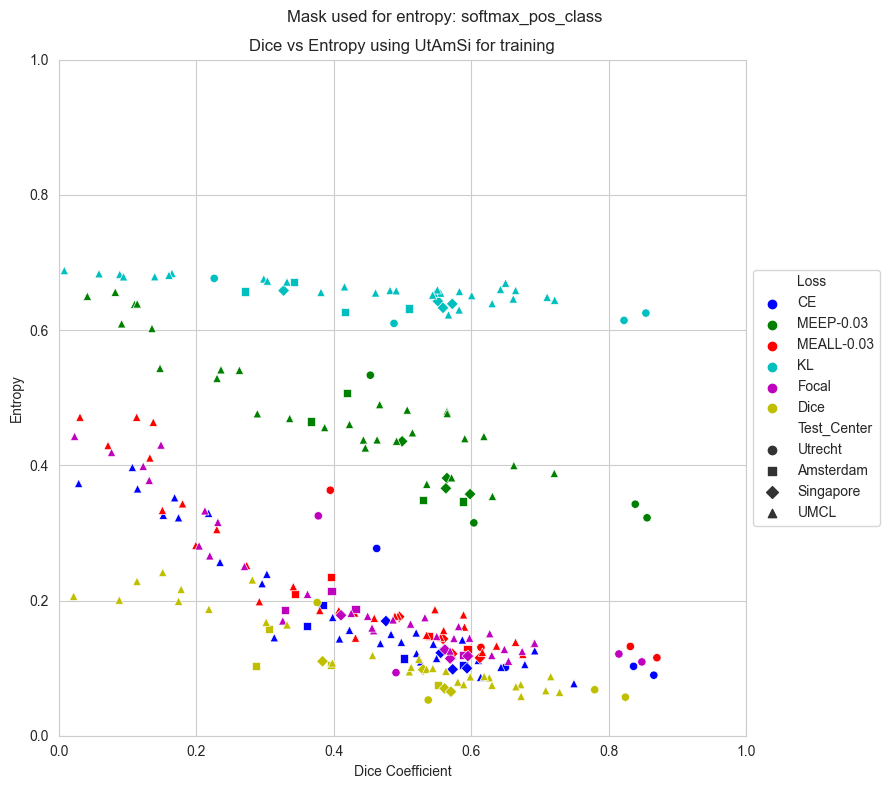

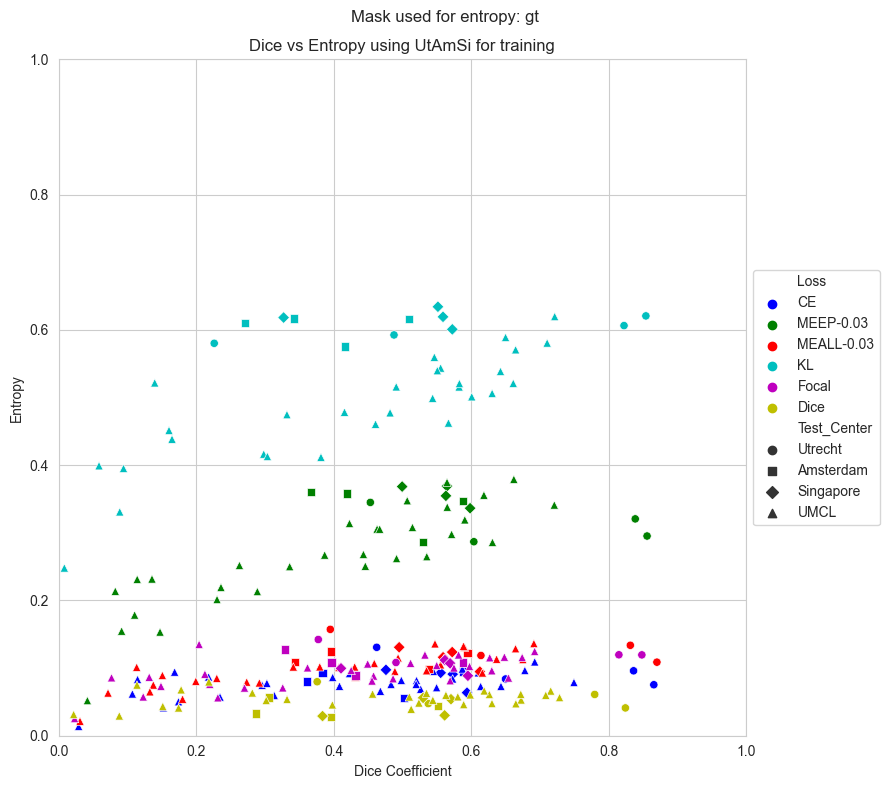

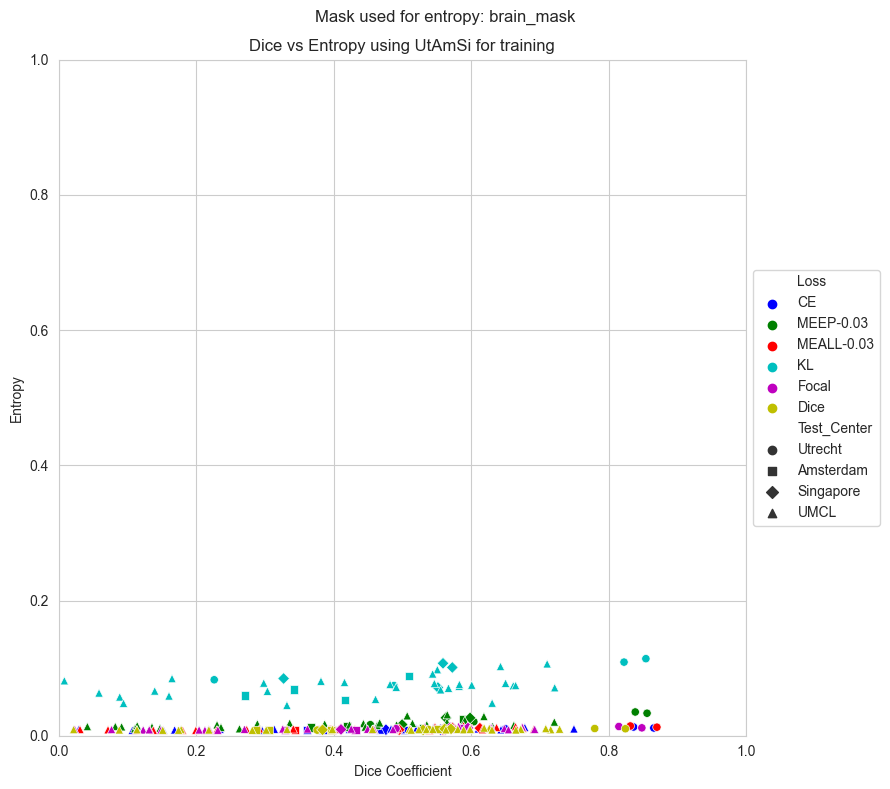

In [16]:
import nibabel as nib
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

filter_pred_with_brain_mask = False

mask_type = ['softmax_pos_class', 'gt', 'brain_mask']
for m_type in mask_type:
    for tr_center in centers_train:  # Three plots: one per center used for training
        plot_data = {}  # Dice vs Entropy scores for each run
        for loss in losses:  # One subplot per loss
            plot_data[loss] = {}
            run_name = runs_to_compare[f'{loss} {tr_center}']
            if f'{loss} {tr_center}' not in runs_to_compare.keys():
                print(f'No run for {run_name}.')
                continue
            for ts_center in centers_test:  # For each center used for testing
                plot_data[loss][ts_center] = []
                gt_pths = get_gt_paths(
                    test_splits[ts_center])  # Lst of tst sbj pts
                for subj_path in gt_pths:
                    gt_path = os.path.join(subj_path,
                                           f'gt_wmh_{run_name}.nii.gz')
                    pred_softmax_path = os.path.join(subj_path,
                                                     f'pred_wmh_softmax_{run_name}.nii.gz')
                    pred_hard_path = os.path.join(subj_path,
                                                  f'pred_wmh_hard_{run_name}.nii.gz')

                    gt = nib.load(gt_path).get_fdata()
                    pred_softmax = nib.load(pred_softmax_path).get_fdata()
                    pred_hard = nib.load(pred_hard_path).get_fdata()
                    b_mask = nib.load(get_b_mask_path(subj_path)).get_fdata()

                    if filter_pred_with_brain_mask:
                        pred_hard = pred_hard * b_mask

                    pos_class = pred_softmax[:, :, :, 1].flatten()
                    gt_class = gt.flatten()
                    b_mask = b_mask.flatten()

                    if m_type == 'softmax_pos_class':
                        filt = pos_class[np.where(pos_class >= 0.5)[0]]
                    elif m_type == 'gt':
                        filt = pos_class[np.where(gt_class == 1)[0]]
                    else:
                        filt = pos_class[np.where(b_mask == 1)[0]]

                    # Compute dice scores
                    dice_hard = dice_score(pred_hard, gt)

                    plot_data[loss][ts_center].append(
                        (dice_hard, entropy(filt)))

        # Create a wide figure with a 16:3 aspect ratio
        fig, ax = plt.subplots(figsize=(9, 8))

        data = []
        colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'w']
        markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*']
        losses = list(plot_data.keys())

        for i, (loss, centers_data) in enumerate(plot_data.items()):
            for center, values in centers_data.items():
                dice_values, entropy_values = zip(*values)
                data.extend([(loss, center, dice, entropy) for dice, entropy in
                             zip(dice_values, entropy_values)])

        df = pd.DataFrame(data,
                          columns=['Loss', 'Test_Center', 'Dice', 'Entropy'])

        # Create the scatter plot
        sns.scatterplot(data=df, x='Dice', y='Entropy', hue='Loss',
                        style='Test_Center',
                        palette=colors[:len(df['Loss'].unique())],
                        markers=markers[:len(df['Test_Center'].unique())],
                        ax=ax)

        ax.set_title(f'Dice vs Entropy using {tr_center} for training')
        ax.set_xlabel('Dice Coefficient')
        ax.set_ylabel('Entropy')
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])

        # Adjust the layout

        plt.suptitle(f'Mask used for entropy: {m_type}')
        plt.tight_layout()
        plt.show()


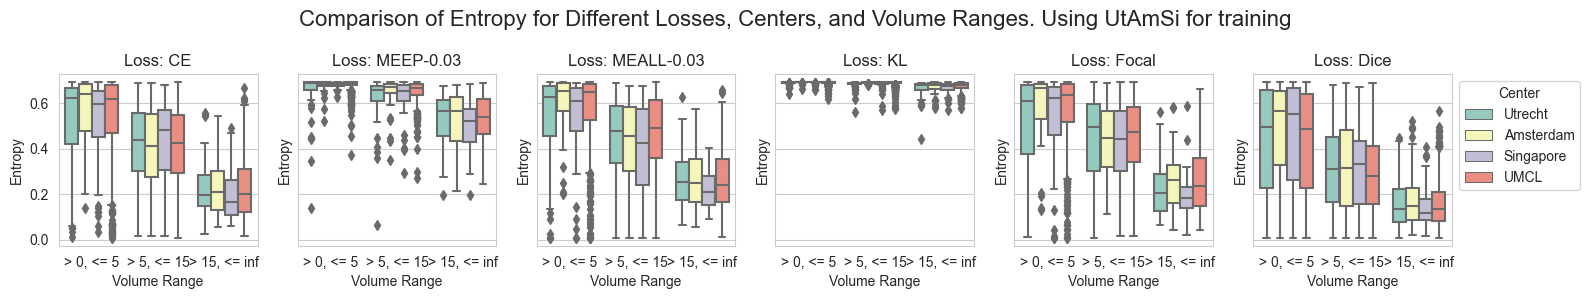

In [17]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import SimpleITK as sitk

volume_ranges = [(0, 5), (5, 15), (15, np.inf)]
for tr_center in centers_train:  # Three plots: one per center used for training
    plot_data = {}  # Entropy scores for each volume range
    for loss in losses:  # One subplot per loss
        plot_data[loss] = {}
        run_name = runs_to_compare[f'{loss} {tr_center}']
        if f'{loss} {tr_center}' not in runs_to_compare.keys():
            print(f'No run for {run_name}.')
            continue
        for ts_center in centers_test:  # For each center used for testing
            plot_data[loss][ts_center] = {
                f"> {volume_ranges[i][0]}, <= {volume_ranges[i][1]}": [] for i
                in range(len(volume_ranges))
            }
            gt_pths = get_gt_paths(test_splits[ts_center])  # Lst of tst sbj pts
            for subj_path in gt_pths:
                pred_softmax_path = os.path.join(subj_path,
                                                 f'pred_wmh_softmax_{run_name}.nii.gz')

                pred_softmax = sitk.ReadImage(pred_softmax_path)
                hard_pred = sitk.GetArrayFromImage(pred_softmax).argmax(axis=0)

                cc = sitk.ConnectedComponent(
                    sitk.GetImageFromArray((hard_pred > 0).astype(np.uint8)))
                cc = sitk.RelabelComponent(cc)

                # For each connected component, compute the volume, then, append to the
                # corresponding list the entropy of the volume in that area.
                # (Multiply for the voxel size to get the volume in mL)
                for i in range(1, sitk.GetArrayFromImage(cc).max() + 1):
                    cc_mask_f = sitk.GetArrayFromImage(cc == i).flatten()
                    filt = np.where(cc_mask_f == 1)[0]
                    volume = len(filt) * np.prod(pred_softmax.GetSpacing())
                    sftmx_f = sitk.GetArrayFromImage(pred_softmax).flatten()[
                        filt]
                    # Compute entropy by first slicing the softmax image with the mask
                    # and then computing the entropy of the slice
                    ent = entropy(sftmx_f)

                    for i, (lower, upper) in enumerate(volume_ranges):
                        if lower < volume <= upper:
                            plot_data[loss][ts_center][
                                f"> {lower}, <= {upper}"].append(ent)
                            break

    # Prepare the data for plotting
    data = []
    losses = list(plot_data.keys())
    centers_test = list(plot_data[losses[0]].keys())
    ranges = list(plot_data[losses[0]][centers_test[0]].keys())

    for loss in losses:
        for center in centers_test:
            for range_label, entropies in plot_data[loss][center].items():
                data.extend(
                    [(loss, center, range_label, ent) for ent in entropies])

    df = pd.DataFrame(data,
                      columns=['Loss', 'Center', 'Volume Range', 'Entropy'])

    # Create subplots for each loss
    fig, axes = plt.subplots(1, len(losses), figsize=(16, 3), sharey=True)
    for i, loss in enumerate(losses):
        # Filter the DataFrame for the current loss
        loss_df = df[df['Loss'] == loss]

        # Create a boxplot for each center within the loss subplot
        sns.boxplot(data=loss_df, x='Volume Range', y='Entropy', hue='Center',
                    ax=axes[i], palette='Set3')

        axes[i].set_title(f'Loss: {loss}')
        axes[i].set_xlabel('Volume Range')
        axes[i].set_ylabel('Entropy')

        # Manually remove the legend for all but the last subplot
        if i < len(losses) - 1:
            axes[i].get_legend().remove()

    # Set the overall title for the entire plot
    fig.suptitle(
        'Comparison of Entropy for Different Losses, Centers, and Volume Ranges'
        f'. Using {tr_center} for training', fontsize=16)

    # Add a single legend outside of the subplots
    handles, labels = axes[-1].get_legend_handles_labels()
    plt.legend(handles, labels, title='Center', loc='upper left',
               bbox_to_anchor=(1, 1))

    # Adjust the layout
    plt.tight_layout()
    plt.show()

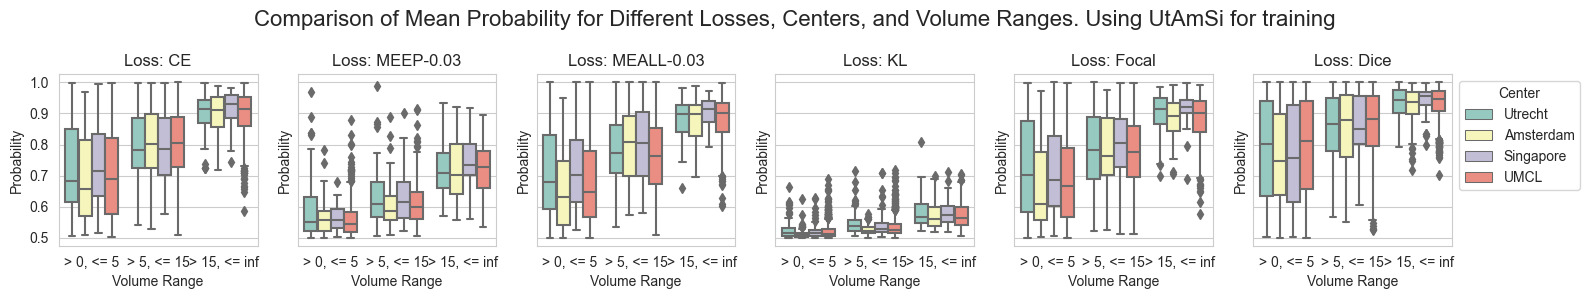

In [18]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import SimpleITK as sitk

volume_ranges = [(0, 5), (5, 15), (15, np.inf)]
for tr_center in centers_train:  # Three plots: one per center used for training
    plot_data = {}  # Mean probability for each volume range
    for loss in losses:  # One subplot per loss
        plot_data[loss] = {}
        run_name = runs_to_compare[f'{loss} {tr_center}']
        if f'{loss} {tr_center}' not in runs_to_compare.keys():
            print(f'No run for {run_name}.')
            continue
        for ts_center in centers_test:  # For each center used for testing
            plot_data[loss][ts_center] = {
                f"> {volume_ranges[i][0]}, <= {volume_ranges[i][1]}": [] for i
                in range(len(volume_ranges))
            }
            gt_pths = get_gt_paths(test_splits[ts_center])  # Lst of tst sbj pts
            for subj_path in gt_pths:
                pred_softmax_path = os.path.join(subj_path,
                                                 f'pred_wmh_softmax_{run_name}.nii.gz')

                pred_softmax = sitk.ReadImage(pred_softmax_path)
                hard_pred = sitk.GetArrayFromImage(pred_softmax).argmax(axis=0)

                cc = sitk.ConnectedComponent(
                    sitk.GetImageFromArray((hard_pred).astype(np.uint8)))
                cc = sitk.RelabelComponent(cc)

                # For each connected component, compute the volume, then, append to the
                # corresponding list the mean probability of the volume in that area.
                # (Multiply for the voxel size to get the volume in mL)
                for i in range(1, sitk.GetArrayFromImage(cc).max() + 1):
                    cc_mask_f = sitk.GetArrayFromImage(cc == i).flatten()
                    filt = np.where(cc_mask_f == 1)[0]
                    volume = len(filt) * np.prod(pred_softmax.GetSpacing())
                    sftmx_f = sitk.GetArrayFromImage(pred_softmax)[1].flatten()[
                        filt]

                    # Compute the mean probability
                    mean_prob = np.mean(sftmx_f)

                    for i, (lower, upper) in enumerate(volume_ranges):
                        if lower < volume <= upper:
                            plot_data[loss][ts_center][
                                f"> {lower}, <= {upper}"].append(mean_prob)
                            break

    # Prepare the data for plotting
    data = []
    losses = list(plot_data.keys())
    centers_test = list(plot_data[losses[0]].keys())
    ranges = list(plot_data[losses[0]][centers_test[0]].keys())

    for loss in losses:
        for center in centers_test:
            for range_label, entropies in plot_data[loss][center].items():
                data.extend(
                    [(loss, center, range_label, ent) for ent in entropies])

    df = pd.DataFrame(data,
                      columns=['Loss', 'Center', 'Volume Range', 'Probability'])

    # Create subplots for each loss
    fig, axes = plt.subplots(1, len(losses), figsize=(16, 3), sharey=True)
    for i, loss in enumerate(losses):
        # Filter the DataFrame for the current loss
        loss_df = df[df['Loss'] == loss]

        # Create a boxplot for each center within the loss subplot
        sns.boxplot(data=loss_df, x='Volume Range', y='Probability',
                    hue='Center', ax=axes[i], palette='Set3')

        axes[i].set_title(f'Loss: {loss}')
        axes[i].set_xlabel('Volume Range')
        axes[i].set_ylabel('Probability')

        # Manually remove the legend for all but the last subplot
        if i < len(losses) - 1:
            axes[i].get_legend().remove()

    # Set the overall title for the entire plot
    fig.suptitle(
        'Comparison of Mean Probability for Different Losses, Centers, and Volume Ranges'
        f'. Using {tr_center} for training', fontsize=16)

    # Add a single legend outside of the subplots
    handles, labels = axes[-1].get_legend_handles_labels()
    plt.legend(handles, labels, title='Center', loc='upper left',
               bbox_to_anchor=(1, 1))

    # Adjust the layout
    plt.tight_layout()
    plt.show()

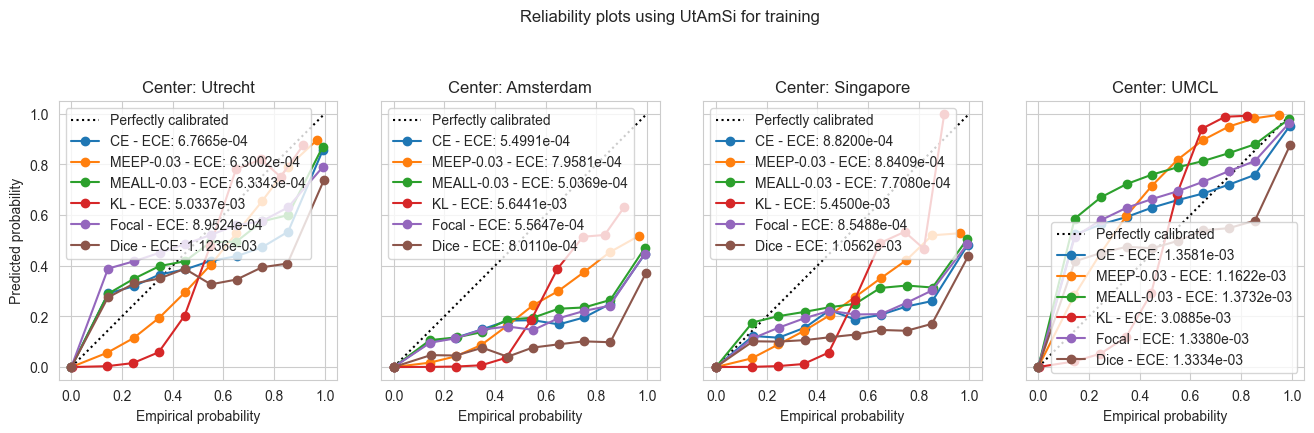

In [19]:
import nibabel as nib
from sklearn.calibration import calibration_curve
from calibration import get_ece
import numpy as np

num_bins = 10

for tr_center in centers_train:  # Three plots: one per center used for training
    plot_data = {}  # Reliability plots
    for loss in losses:  # One subplot per loss
        plot_data[loss] = {}
        run_name = runs_to_compare[f'{loss} {tr_center}']
        if f'{loss} {tr_center}' not in runs_to_compare.keys():
            print(f'No run for {run_name}.')
            continue
        for ts_center in centers_test:  # For each center used for testing
            gt_pths = get_gt_paths(test_splits[ts_center])  # Lst of tst sbj pts
            preds_arr, gts_arr = [], []
            for subj_path in gt_pths:
                gt_path = os.path.join(subj_path, f'gt_wmh_{run_name}.nii.gz')
                pred_softmax_path = os.path.join(subj_path,
                                                 f'pred_wmh_softmax_{run_name}.nii.gz')

                pred_softmax = nib.load(pred_softmax_path).get_fdata()
                gt = nib.load(gt_path).get_fdata()
                gt_one_hot = np.eye(2, dtype=np.uint8)[gt.astype(int)]

                preds_arr = np.concatenate(
                    (preds_arr, pred_softmax[..., 1].flatten()))
                gts_arr = np.concatenate(
                    (gts_arr, gt_one_hot[..., 1].flatten()))

            emp_probs, pred_probs = calibration_curve(gts_arr, preds_arr,
                                                      n_bins=num_bins)
            plot_data[loss][ts_center] = {
                'emp_probs': emp_probs,
                'pred_probs': pred_probs,
                'ece': get_ece(preds_arr, gts_arr.astype(int))
            }

    fig, axes = plt.subplots(1, len(centers_test), figsize=(13.5, 4.5),
                             sharey=True)

    [axes[i].plot([0, 1], [0, 1], 'k:', label='Perfectly calibrated') for i in
     range(len(centers_test))]
    for loss, ts_center_data in plot_data.items():
        for i, (ts_center, data) in enumerate(ts_center_data.items()):
            ax = axes[i]

            # Extract data from plot_data
            emp_probs = data['emp_probs']
            pred_probs = data['pred_probs']
            ece = data['ece']

            ax.plot(pred_probs, emp_probs, 'o-',
                    label=f'{loss} - ECE: {ece:.4e}')
            ax.set_xlabel('Predicted probability')
            ax.set_ylabel('Empirical probability')
            ax.set_ylim([-0.05, 1.05])
            ax.legend()

            # Set titles, labels, and other formatting
            ax.set_title(f'Center: {ts_center}')
            ax.set_xlabel('Empirical probability')
            ax.set_ylabel('Predicted probability')

            # Make the subplot square
            ax.set_aspect('equal', 'box')

    for ax in axes[1:]:
        ax.set_ylabel('')

    plt.suptitle(f'Reliability plots using {tr_center} for training')

    # Adjust layout
    plt.tight_layout()

    # Show the plot
    plt.show()  

In [ ]:
import nibabel as nib
from sklearn.calibration import calibration_curve
from calibration import get_ece
import numpy as np

num_bins = 10

for tr_center in centers_train:  # Three plots: one per center used for training
    plot_data = {}  # Reliability plots
    for loss in losses:  # One subplot per loss
        run_name = runs_to_compare[f'{loss} {tr_center}']
        if f'{loss} {tr_center}' not in runs_to_compare.keys():
            print(f'No run for {run_name}.')
            continue
        preds_arr, gts_arr = [], []
        for ts_center in centers_test:  # For each center used for testing
            gt_pths = get_gt_paths(test_splits[ts_center])  # Lst of tst sbj pts
            for subj_path in gt_pths:
                gt_path = os.path.join(subj_path, f'gt_wmh_{run_name}.nii.gz')
                pred_softmax_path = os.path.join(subj_path,
                                                 f'pred_wmh_softmax_{run_name}.nii.gz')

                pred_softmax = nib.load(pred_softmax_path).get_fdata()
                gt = nib.load(gt_path).get_fdata()
                gt_one_hot = np.eye(2, dtype=np.uint8)[gt.astype(int)]

                preds_arr = np.concatenate(
                    (preds_arr, pred_softmax[..., 1].flatten()))
                gts_arr = np.concatenate(
                    (gts_arr, gt_one_hot[..., 1].flatten()))

        emp_probs, pred_probs = calibration_curve(gts_arr, preds_arr,
                                                  n_bins=num_bins)
        plot_data[loss] = {
            'emp_probs': emp_probs,
            'pred_probs': pred_probs,
            'ece': get_ece(preds_arr, gts_arr.astype(int))
        }
fig, ax = plt.subplots(figsize=(4.5, 4.5))

ax.plot([0, 1], [0, 1], 'k:', label='Perfectly calibrated')
for loss, data in plot_data.items():
    # Extract data from plot_data
    emp_probs = data['emp_probs']
    pred_probs = data['pred_probs']
    ece = data['ece']

    ax.plot(pred_probs, emp_probs, 'o-',
            label=f'{loss} - ECE: {ece:.4e}')
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Empirical probability')
    ax.set_ylim([-0.05, 1.05])
    ax.legend()

    # Set titles, labels, and other formatting
    ax.set_title(f'Center: {tr_center}')
    ax.set_xlabel('Empirical probability')
    ax.set_ylabel('Predicted probability')

    # Make the subplot square
    ax.set_aspect('equal', 'box')

plt.suptitle(f'Reliability plots using {tr_center} for training')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()
